In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

## Load dataset

In [2]:
def load_data(file_path):
    try:
        data = pd.read_csv(file_path)
        return data
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return None

df = load_data("../dataset/store_sales.csv")

In [3]:
df.head(10)

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10
5,6,48,Male,Groceries,Snacks,36.76,Autumn,Card,2.5,14,2
6,7,54,Male,Electronics,Mobile Phone,1396.16,Autumn,Card,4.7,18,4
7,8,59,Female,Beauty,Perfume,35.55,Summer,Card,4.6,14,7
8,9,51,Male,Electronics,Smart Watch,2238.79,Spring,Card,4.3,20,5
9,10,47,Female,Footwear,Formal Shoes,225.49,Spring,Card,4.7,18,4


## Feature engineering

#### - **Create sales column**
#### - **Data cleaning for ensure clean data**
#### - **Create columns relation based on CustomerID**

In [4]:
# Rename Amount column to Price
df = df.rename(columns={"Amount": "Price"})
df["Sales"] = df["Price"] * (1 - df["DiscountApplied(%)"] / 100) # Create sales column

"""Behavior signals"""
df["Discount_value"] = df["Price"] - df["Sales"]
df["Discount_ratio"] = df["Discount_value"] / df["Price"]
df["Is_loyal_customer"] = df["PreviousPurchases"].apply(lambda x : 1 if x > 5 else 0)
df["High_rating"] = df["ItemRating"].apply(lambda x : 1 if x >= 4 else 0)

In [5]:
df.head(10)

,CustomerID,Age,Gender,Category,ItemPurchased,Price,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases,Sales,Discount_value,Discount_ratio,Is_loyal_customer,High_rating
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4,94.7100,20.7900,0.18,0,0
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4,89.9841,13.4459,0.13,0,1
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3,31.5505,3.8995,0.11,0,0
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4,133.3797,19.9303,0.13,0,1
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10,121.1440,30.2860,0.20,1,1
5,6,48,Male,Groceries,Snacks,36.76,Autumn,Card,2.5,14,2,31.6136,5.1464,0.14,0,0
6,7,54,Male,Electronics,Mobile Phone,1396.16,Autumn,Card,4.7,18,4,1144.8512,251.3088,0.18,0,1
7,8,59,Female,Beauty,Perfume,35.55,Summer,Card,4.6,14,7,30.5730,4.9770,0.14,1,1
8,9,51,Male,Electronics,Smart Watch,2238.79,Spring,Card,4.3,20,5,1791.0320,447.7580,0.20,0,1
9,10,47,Female,Footwear,Formal Shoes,225.49,Spring,Card,4.7,18,4,184.9018,40.5882,0.18,0,1


## Data visualization analysis

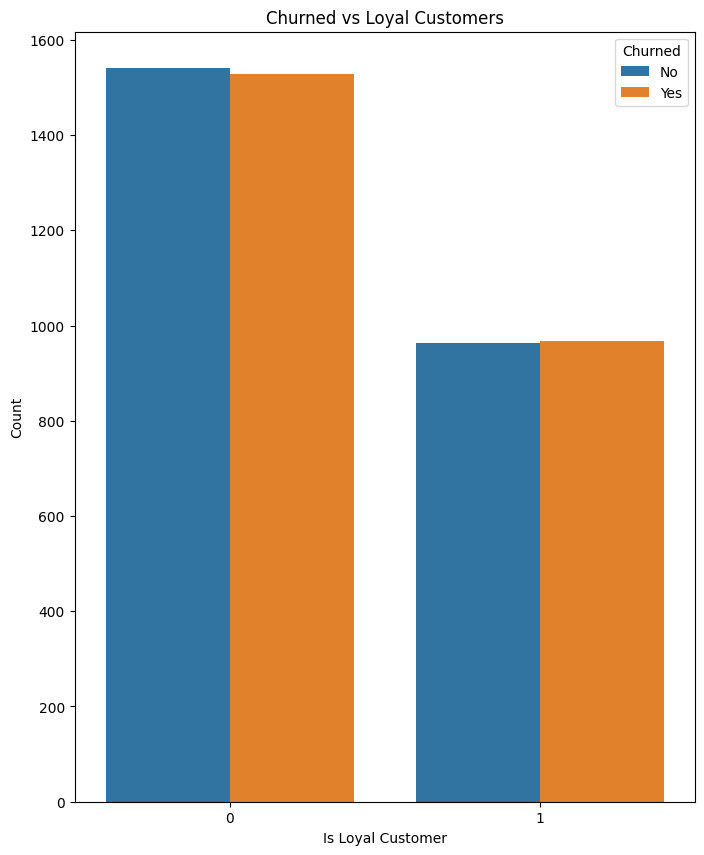

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# analyze churn customer based on Is_loyal_customer
plt.figure(figsize=(8, 10))
sns.countplot(x="Is_loyal_customer", hue="Gender", data=df)
plt.title("Churned vs Loyal Customers")
plt.xlabel("Is Loyal Customer")
plt.ylabel("Count")
plt.legend(title="Churned", labels=["No", "Yes"])
plt.show()

# Data encoding

In [7]:
# Encoding data categorical data
from sklearn.preprocessing import LabelEncoder

cat_cols = [col for col in df.columns if df[col].dtype == "object"]
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    label_encoder = le

# Split data into X and y

In [8]:
# Split data into X and y
X = df.drop(columns=["CustomerID", "Sales", "Season"])
y = df["Sales"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Minmax data

In [11]:
from sklearn.preprocessing import StandardScaler

num_cols = X_train.select_dtypes(include=np.number).columns
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## Machine learning models for handling business problem

In [12]:
# Machine learning models regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score, GridSearchCV

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

# Train and evaluate all models
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Metrics
    results[name] = {
        "R2 Train": r2_score(y_train, y_pred_train),
        "R2 Test": r2_score(y_test, y_pred_test),
        "MAE": mean_absolute_error(y_test, y_pred_test),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred_test),
        "RMSE" : mean_squared_error(y_test, y_pred_test, squared=False),
        "CV R2 Mean": cross_val_score(model, X_train, y_train, cv=5, scoring="r2").mean()
    }

    print(f"\n{'='*45}")
    print(f"Model: {name}")
    print(f"{'='*45}")
    for metric, value in results[name].items():
        print(f"{metric}: {value:.4f}")

# Baseline summary
baseline_df = pd.DataFrame(results).T.sort_values(by="R2 Test", ascending=False).round(4)
print("\nModel Performance Summary:")
print(baseline_df.to_string())

# ══════════════════════════════════════════════════════════════
#  PHASE 2 : GridSearchCV – Hyperparameter Tuning All Models
# ══════════════════════════════════════════════════════════════
print("\n\n" + "="*55)
print("       PHASE 2 : GRIDSEARCHCV TUNING ALL MODELS")
print("="*55)

param_grids = {
    "Linear Regression": {
        "fit_intercept": [True, False],
        "positive": [True, False]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf":  [1, 2, 4]
    },
    "XGBoost": {
        "n_estimators":     [100, 200, 300],
        "max_depth":        [3, 5, 7],
        "learning_rate":    [0.01, 0.05, 0.1, 0.2],
        "subsample":        [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0]
    },
    "Decision Tree": {
        "max_depth":         [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf":  [1, 2, 4],
        "criterion":         ["squared_error", "absolute_error"]
    }
}

best_models = {}
best_params = {}
gridsearch_results = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  GridSearchCV : {name}")
    print(f"{'='*55}")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_
    best_params[name] = grid_search.best_params_

    y_pred_train = grid_search.best_estimator_.predict(X_train)
    y_pred_test = grid_search.best_estimator_.predict(X_test)

    gridsearch_results[name] = {
        "Best CV R2": grid_search.best_score_,
        "R2 Train":   r2_score(y_train, y_pred_train),
        "R2 Test":    r2_score(y_test,  y_pred_test),
        "MAE":        mean_absolute_error(y_test, y_pred_test),
        "MAPE":       mean_absolute_percentage_error(y_test, y_pred_test),
        "RMSE":       np.sqrt(mean_squared_error(y_test, y_pred_test))
    }

    print(f"\n  ✅ Best Parameters : {grid_search.best_params_}")
    print(f"  ✅ Best CV R2      : {grid_search.best_score_:.4f}")

# ── Best Parameters Summary ───────────────────────────────────
print("\n\n" + "="*55)
print("       BEST PARAMETERS FOR EACH MODEL")
print("="*55)
for name, params in best_params.items():
    print(f"\n{name}")
    for param, value in params.items():
        print(f"  - {param}: {value}")

# ── Tuned Results Summary DataFrame ──────────────────────────
tuned_df = pd.DataFrame(gridsearch_results).T.sort_values("R2 Test", ascending=False).round(4)
print("\n\n" + "="*55)
print("       MODEL PERFORMANCE AFTER GRIDSEARCHCV")
print("="*55)
print(tuned_df.to_string())

# ── Best Overall Model ────────────────────────────────────────
best_model_name = tuned_df["R2 Test"].idxmax()
print(f"\n🏆 Best Model Overall : {best_model_name}")
print(f"   Best CV R2 : {tuned_df.loc[best_model_name, 'Best CV R2']:.4f}")
print(f"   R2 Train   : {tuned_df.loc[best_model_name, 'R2 Train']:.4f}")
print(f"   R2 Test    : {tuned_df.loc[best_model_name, 'R2 Test']:.4f}")
print(f"   MAE        : {tuned_df.loc[best_model_name, 'MAE']:.4f}")
print(f"   MAPE       : {tuned_df.loc[best_model_name, 'MAPE']:.4f}")
print(f"   RMSE       : {tuned_df.loc[best_model_name, 'RMSE']:.4f}")


Model: Linear Regression
R2 Train: 1.0000
R2 Test: 1.0000
MAE: 0.0000
MAPE: 0.0000
RMSE: 0.0000
CV R2 Mean: 1.0000


KeyboardInterrupt: 

In [10]:
# ══════════════════════════════════════════════════════════════
#  PHASE 4 : Save All Models & Metrics
# ══════════════════════════════════════════════════════════════
#import os
#import joblib
#import json
#from datetime import datetime

# ── Create Save Directory ─────────────────────────────────────
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ══════════════════════════════════════════════════════════════
#  1. Save All Tuned Models (.pkl)
# ══════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("       SAVING MODELS")
print("="*55)

for name, model in best_models.items():
    # clean filename
    model_filename = f"{save_dir}/{name.replace(' ', '_')}_{timestamp}.pkl"
    joblib.dump(model, model_filename)
    print(f"  ✅ Saved : {model_filename}")

# ── Also save best overall model separately ───────────────────
best_model_filename = f"{save_dir}/BEST_MODEL_{best_model_name.replace(' ', '_')}_{timestamp}.pkl"
joblib.dump(best_models[best_model_name], best_model_filename)
print(f"\n  🏆 Best Model Saved : {best_model_filename}")

# ══════════════════════════════════════════════════════════════
#  2. Save Metrics to CSV
# ══════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("       SAVING METRICS")
print("="*55)

# ── Baseline Metrics CSV ──────────────────────────────────────
baseline_csv = f"{save_dir}/baseline_metrics_{timestamp}.csv"
baseline_df.to_csv(baseline_csv, index=True)
print(f"  ✅ Baseline Metrics  : {baseline_csv}")

# ── Tuned Metrics CSV ─────────────────────────────────────────
tuned_csv = f"{save_dir}/tuned_metrics_{timestamp}.csv"
tuned_df.to_csv(tuned_csv, index=True)
print(f"  ✅ Tuned Metrics     : {tuned_csv}")

# ── Combined Baseline vs Tuned CSV ───────────────────────────
baseline_df_copy        = baseline_df.copy()
tuned_df_copy           = tuned_df.copy()
baseline_df_copy.index  = [f"{n} (Baseline)" for n in baseline_df_copy.index]
tuned_df_copy.index     = [f"{n} (Tuned)"    for n in tuned_df_copy.index]

# align columns for concat
common_cols = ["R2 Train", "R2 Test", "MAE", "MAPE", "RMSE"]
combined_df = pd.concat([baseline_df_copy[common_cols],
                         tuned_df_copy[common_cols]])
combined_df = combined_df.round(4)

combined_csv = f"{save_dir}/combined_metrics_{timestamp}.csv"
combined_df.to_csv(combined_csv, index=True)
print(f"  ✅ Combined Metrics  : {combined_csv}")

# ══════════════════════════════════════════════════════════════
#  3. Save Best Parameters to JSON
# ══════════════════════════════════════════════════════════════
# Convert None values for JSON serialization
def convert_params(params_dict):
    converted = {}
    for model_name, params in params_dict.items():
        converted[model_name] = {
            k: (str(v) if v is None else v)
            for k, v in params.items()
        }
    return converted

params_filename = f"{save_dir}/best_params_{timestamp}.json"
with open(params_filename, "w") as f:
    json.dump(convert_params(best_params), f, indent=4)
print(f"\n  ✅ Best Parameters   : {params_filename}")

# ══════════════════════════════════════════════════════════════
#  4. Save Full Summary Report to TXT
# ══════════════════════════════════════════════════════════════
report_filename = f"{save_dir}/summary_report_{timestamp}.txt"

with open(report_filename, "w") as f:
    f.write("="*55 + "\n")
    f.write(f"  MODEL TRAINING SUMMARY REPORT\n")
    f.write(f"  Generated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("="*55 + "\n\n")

    # Baseline
    f.write("── PHASE 1 : BASELINE PERFORMANCE ──\n\n")
    f.write(baseline_df.to_string())
    f.write("\n\n")

    # Best Params
    f.write("── PHASE 2 : BEST PARAMETERS (GridSearchCV) ──\n\n")
    for name, params in best_params.items():
        f.write(f"  📌 {name}\n")
        for param, value in params.items():
            f.write(f"     {param:<25}: {value}\n")
        f.write("\n")

    # Tuned Results
    f.write("── PHASE 2 : TUNED MODEL PERFORMANCE ──\n\n")
    f.write(tuned_df.to_string())
    f.write("\n\n")

    # Combined
    f.write("── BASELINE vs TUNED COMPARISON ──\n\n")
    f.write(combined_df.to_string())
    f.write("\n\n")

    # Best Model
    f.write("="*55 + "\n")
    f.write(f"  🏆 BEST MODEL : {best_model_name}\n")
    f.write("="*55 + "\n")
    for metric in common_cols:
        f.write(f"   {metric:<12}: {tuned_df.loc[best_model_name, metric]:.4f}\n")

print(f"  ✅ Summary Report    : {report_filename}")

# ══════════════════════════════════════════════════════════════
#  5. Print Final File Summary
# ══════════════════════════════════════════════════════════════
print("\n\n" + "="*55)
print("       ALL FILES SAVED SUCCESSFULLY")
print("="*55)
print(f"\n  📁 Directory : {save_dir}/")

all_files = sorted(os.listdir(save_dir))
for file in all_files:
    size = os.path.getsize(f"{save_dir}/{file}")
    print(f"     {file:<55} {size/1024:>8.2f} KB")

# ══════════════════════════════════════════════════════════════
#  6. Load Model Example (How to reload)
# ══════════════════════════════════════════════════════════════
print("\n\n" + "="*55)
print("       HOW TO RELOAD SAVED MODELS")
print("="*55)
print("""
  # Load a specific model
  import joblib
  model = joblib.load('saved_models/Random_Forest_<timestamp>.pkl')
  y_pred = model.predict(X_test)

  # Load best model
  best_model = joblib.load('saved_models/BEST_MODEL_<model_name>_<timestamp>.pkl')
  y_pred = best_model.predict(X_test)

  # Load metrics
  import pandas as pd
  tuned_df   = pd.read_csv('saved_models/tuned_metrics_<timestamp>.csv', index_col=0)
  baseline_df = pd.read_csv('saved_models/baseline_metrics_<timestamp>.csv', index_col=0)

  # Load best params
  import json
  with open('saved_models/best_params_<timestamp>.json') as f:
      best_params = json.load(f)
""")

NameError: name 'os' is not defined